# Extensión del análisis: prerrequisitos de Métodos Numéricos

## Objetivo

Este notebook extiende el análisis original manteniendo la misma pregunta de investigación:

**¿Qué factores académicos disponibles después del primer parcial permiten estimar la probabilidad de que un estudiante de Métodos Numéricos alcance una firma final de 71 puntos o más?**

En esta extensión se incorpora información del prerrequisito de Métodos Numéricos. Para este análisis, **Ecuaciones Diferenciales** y **Cálculo 3** se consideran asignaturas equivalentes para cumplir dicho prerrequisito.

El objetivo es determinar si el rendimiento previo en estas asignaturas aporta información adicional al modelo ya desarrollado.

## 1. Importación de librerías

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

## 2. Carga de los datos

Se utilizan:

- el dataset completo construido para la cohorte de Métodos Numéricos 2025-2;
- el archivo académico correspondiente al segundo ciclo de 2024, donde se encuentran registros de Ecuaciones Diferenciales y Cálculo 3.

La cohorte original se mantiene sin modificaciones.

In [75]:
ruta_cohorte = "../data/dataset_metodos_numericos_completo.csv"
ruta_2024_2 = "../data/rendimiento_año_2024_ciclo_2_anon.xlsx"

cohorte_mn = pd.read_csv(ruta_cohorte)
df_2024_2 = pd.read_excel(ruta_2024_2)

print("Cohorte de Métodos Numéricos:", cohorte_mn.shape)
print("Datos 2024-2:", df_2024_2.shape)

Cohorte de Métodos Numéricos: (260, 10)
Datos 2024-2: (24468, 28)


## 3. Verificación de la cohorte original

In [76]:
print("Cantidad de filas:", len(cohorte_mn))
print("Estudiantes únicos:", cohorte_mn["ALUMNO_ID"].nunique())
print("Casos que alcanzan firma >= 71:", cohorte_mn["exonera"].sum())

Cantidad de filas: 260
Estudiantes únicos: 260
Casos que alcanzan firma >= 71: 34


## 4. Identificación del prerrequisito

Para cursar Métodos Numéricos, el prerrequisito puede corresponder a `ECUACIONES DIFERENCIALES` o `CALCULO 3`.

Ambas asignaturas se consideran equivalentes para esta extensión y se analizan como una única fuente de información académica previa.

In [77]:
asignaturas_prerrequisito = [
    "ECUACIONES DIFERENCIALES",
    "CALCULO 3"
]

prerrequisito_2024 = df_2024_2[
    df_2024_2["Asignatura"].isin(asignaturas_prerrequisito)
].copy()

print("Registros del prerrequisito:", len(prerrequisito_2024))
print("Estudiantes únicos:", prerrequisito_2024["ALUMNO_ID"].nunique())

print("\nDistribución por asignatura:")
print(prerrequisito_2024["Asignatura"].value_counts())

Registros del prerrequisito: 653
Estudiantes únicos: 653

Distribución por asignatura:
Asignatura
ECUACIONES DIFERENCIALES    647
CALCULO 3                     6
Name: count, dtype: int64


## 5. Cruce con la cohorte de Métodos Numéricos

Se identifican los estudiantes de Métodos Numéricos 2025-2 que poseen un registro del prerrequisito en 2024-2.

Como esta información corresponde a un período anterior al objetivo, puede utilizarse sin producir *data leakage*.

In [78]:
ids_mn = set(cohorte_mn["ALUMNO_ID"])

prerrequisito_cohorte = prerrequisito_2024[
    prerrequisito_2024["ALUMNO_ID"].isin(ids_mn)
].copy()

print("Estudiantes de Métodos Numéricos:", len(ids_mn))
print(
    "Con registro del prerrequisito en 2024:",
    prerrequisito_cohorte["ALUMNO_ID"].nunique()
)
print(
    "Sin registro del prerrequisito en 2024:",
    len(ids_mn - set(prerrequisito_cohorte["ALUMNO_ID"]))
)

print("\nDistribución dentro de la cohorte:")
print(prerrequisito_cohorte["Asignatura"].value_counts())

Estudiantes de Métodos Numéricos: 260
Con registro del prerrequisito en 2024: 100
Sin registro del prerrequisito en 2024: 160

Distribución dentro de la cohorte:
Asignatura
ECUACIONES DIFERENCIALES    98
CALCULO 3                    2
Name: count, dtype: int64


In [79]:
cobertura_prerrequisito = (
    prerrequisito_cohorte["ALUMNO_ID"].nunique()
    / cohorte_mn["ALUMNO_ID"].nunique()
    * 100
)

print(f"Cobertura del prerrequisito: {cobertura_prerrequisito:.2f}%")

Cobertura del prerrequisito: 38.46%


### Consideración sobre la cobertura

La ausencia de un registro en 2024-2 **no significa** que el estudiante no haya cursado o firmado el prerrequisito. Es posible que lo haya realizado en otro período no disponible en este archivo.

Por este motivo, los registros ausentes no se imputarán como cero.

## 6. Revisión de estudiantes con más de una asignatura equivalente

Se verifica si algún estudiante posee registros tanto de Ecuaciones Diferenciales como de Cálculo 3.

Si existieran múltiples registros, se consolidarán antes de construir las nuevas variables.

In [80]:
conteo_por_alumno = (
    prerrequisito_cohorte
    .groupby("ALUMNO_ID")["Asignatura"]
    .nunique()
)

print(
    "Estudiantes con más de una asignatura equivalente:",
    (conteo_por_alumno > 1).sum()
)

ids_multiples = conteo_por_alumno[conteo_por_alumno > 1].index

prerrequisito_cohorte[
    prerrequisito_cohorte["ALUMNO_ID"].isin(ids_multiples)
].sort_values(["ALUMNO_ID", "Asignatura"])

Estudiantes con más de una asignatura equivalente: 0


,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,Anho.Firma,Primer.Par,Segundo.Par,Tercer.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final


## 7. Revisión de las variables disponibles

Se analizan las variables académicas que podrían representar el rendimiento previo del estudiante en el prerrequisito.

In [81]:
columnas_prerrequisito = [
    "ALUMNO_ID",
    "Cod.Asign",
    "Asignatura",
    "Anho.Firma",
    "Primer.Par",
    "Segundo.Par",
    "Primer.Rec",
    "Segundo.Rec",
    "Firma",
    "Nota.Final",
    "Aprobado"
]

prerrequisito_cohorte[columnas_prerrequisito].head(10)

,ALUMNO_ID,Cod.Asign,Asignatura,Anho.Firma,Primer.Par,Segundo.Par,Primer.Rec,Segundo.Rec,Firma,Nota.Final,Aprobado
550,FIUNA_ALUMNO_010903,13013,CALCULO 3,2024,0,0,0,0,45.0,2F-2,S
551,FIUNA_ALUMNO_011282,13013,CALCULO 3,2024,0,0,0,0,45.0,2F-2,S
18925,FIUNA_ALUMNO_006031,23032,ECUACIONES DIFERENCIALES,2024,56,7,42,0,50.0,2F-3,S
18926,FIUNA_ALUMNO_007861,23032,ECUACIONES DIFERENCIALES,2024,56,7,42,0,50.0,2F-3,S
18951,FIUNA_ALUMNO_009866,23032,ECUACIONES DIFERENCIALES,2024,71,67,0,0,71.0,1F-3,S
18952,FIUNA_ALUMNO_010563,23032,ECUACIONES DIFERENCIALES,2024,71,67,0,0,71.0,1F-3,S
18953,FIUNA_ALUMNO_012009,23032,ECUACIONES DIFERENCIALES,2024,51,78,0,0,68.0,1F-2,S
18954,FIUNA_ALUMNO_012135,23032,ECUACIONES DIFERENCIALES,2024,51,78,0,0,68.0,1F-2,S
18955,FIUNA_ALUMNO_006964,23032,ECUACIONES DIFERENCIALES,2024,71,73,0,0,72.0,1F-3,S
18956,FIUNA_ALUMNO_009504,23032,ECUACIONES DIFERENCIALES,2024,71,73,0,0,72.0,1F-3,S


In [82]:
prerrequisito_cohorte[
    [
        "Firma",
        "Primer.Par",
        "Segundo.Par",
        "Primer.Rec",
        "Segundo.Rec"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Firma,100.0,62.42,11.173725,45.0,52.0,61.5,71.0,91.0
Primer.Par,100.0,57.48,20.177235,0.0,44.0,59.0,71.0,93.0
Segundo.Par,100.0,57.78,23.337047,0.0,50.0,59.5,73.0,100.0
Primer.Rec,100.0,15.60,21.393854,0.0,0.0,0.0,39.0,57.0
Segundo.Rec,100.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.0


## 8. Firma del prerrequisito

La existencia de firma habilita el avance hacia Métodos Numéricos, pero el **puntaje de firma** presenta variabilidad entre estudiantes y puede contener información adicional sobre su desempeño previo.

In [83]:
prerrequisito_cohorte["Firma"].describe()

count    100.000000
mean      62.420000
std       11.173725
min       45.000000
25%       52.000000
50%       61.500000
75%       71.000000
max       91.000000
Name: Firma, dtype: float64

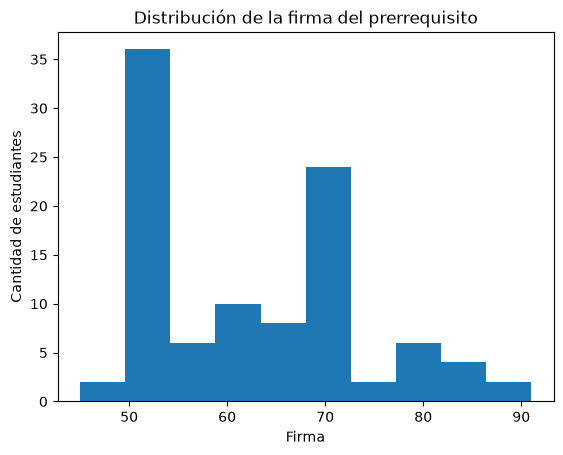

In [84]:
plt.hist(prerrequisito_cohorte["Firma"], bins=10)

plt.title("Distribución de la firma del prerrequisito")
plt.xlabel("Firma")
plt.ylabel("Cantidad de estudiantes")
plt.show()

### Año de obtención de la firma

Se comprueba que los registros utilizados correspondan a información anterior al período objetivo.

In [85]:
prerrequisito_cohorte["Anho.Firma"].value_counts(dropna=False)

Anho.Firma
2024    100
Name: count, dtype: int64

## 9. Aprobación del prerrequisito

Además del puntaje de firma, se construye una variable binaria que indica si el estudiante aprobó la asignatura prerrequisito.

In [86]:
prerrequisito_cohorte["aprobo_prerrequisito"] = (
    prerrequisito_cohorte["Aprobado"]
    .map({
        "S": 1,
        "N": 0
    })
)

prerrequisito_cohorte["aprobo_prerrequisito"].value_counts(dropna=False)

aprobo_prerrequisito
1    88
0    12
Name: count, dtype: int64

## 10. Revisión de `Nota.Final`

`Nota.Final` combina información sobre convocatoria y calificación, por ejemplo valores como `1F-3` o `2F-2`.

Por este motivo no se utiliza directamente como predictor en esta extensión.

In [87]:
prerrequisito_cohorte["Nota.Final"].value_counts(dropna=False).head(20)

Nota.Final
1F-3         26
2F-2         18
2F-3         14
1F-2         10
2F-1          6
NaN           6
1F-4          6
2F-4          2
1F-1,2F-4     2
2F-5          2
1F-1,2F-5     2
1F-1,2F-2     2
1F-5          2
1F-1,2F-3     2
Name: count, dtype: int64

## 11. Revisión de recuperatorios

Los recuperatorios pueden modificar el rendimiento y su efecto puede quedar reflejado en la firma final del prerrequisito.

In [88]:
print("Primer recuperatorio:")
print(prerrequisito_cohorte["Primer.Rec"].describe())

print("\nSegundo recuperatorio:")
print(prerrequisito_cohorte["Segundo.Rec"].describe())

print(
    "\nEstudiantes con Primer.Rec > 0:",
    (prerrequisito_cohorte["Primer.Rec"] > 0).sum()
)

print(
    "Estudiantes con Segundo.Rec > 0:",
    (prerrequisito_cohorte["Segundo.Rec"] > 0).sum()
)

Primer recuperatorio:
count    100.000000
mean      15.600000
std       21.393854
min        0.000000
25%        0.000000
50%        0.000000
75%       39.000000
max       57.000000
Name: Primer.Rec, dtype: float64

Segundo recuperatorio:
count    100.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Segundo.Rec, dtype: float64

Estudiantes con Primer.Rec > 0: 36
Estudiantes con Segundo.Rec > 0: 0


## 12. Consolidación de las asignaturas equivalentes

Para generar una sola fila por estudiante se consolidan Ecuaciones Diferenciales y Cálculo 3.

Si un estudiante tuviera más de un registro equivalente:

- se conserva la **mejor firma previa**;
- `aprobo_prerrequisito` toma valor 1 si aprobó al menos uno de los registros.

Esta regla evita duplicar estudiantes en el dataset final.

In [89]:
features_prerrequisito = (
    prerrequisito_cohorte
    .groupby("ALUMNO_ID", as_index=False)
    .agg(
        firma_prerrequisito=("Firma", "max"),
        aprobo_prerrequisito=("aprobo_prerrequisito", "max")
    )
)

print("Filas:", len(features_prerrequisito))
print("Estudiantes únicos:", features_prerrequisito["ALUMNO_ID"].nunique())

features_prerrequisito.head()

Filas: 100
Estudiantes únicos: 100


,ALUMNO_ID,firma_prerrequisito,aprobo_prerrequisito
0,FIUNA_ALUMNO_006031,50.0,1
1,FIUNA_ALUMNO_006964,72.0,1
2,FIUNA_ALUMNO_007090,54.0,1
3,FIUNA_ALUMNO_007861,50.0,1
4,FIUNA_ALUMNO_008979,50.0,1


In [90]:
features_prerrequisito.describe()

,firma_prerrequisito,aprobo_prerrequisito
count,100.000000,100.000000
mean,62.420000,0.880000
std,11.173725,0.326599
min,45.000000,0.000000
25%,52.000000,1.000000
50%,61.500000,1.000000
75%,71.000000,1.000000
max,91.000000,1.000000


## 13. Unión con la cohorte original

Se realiza un `left join` para conservar los 260 estudiantes originales.

Los valores faltantes en las nuevas variables indican que no se encontró el prerrequisito en el archivo 2024-2; no se reemplazan por cero.

In [91]:
dataset_extension = cohorte_mn.merge(
    features_prerrequisito,
    on="ALUMNO_ID",
    how="left"
)

print("Dimensiones:", dataset_extension.shape)

print("\nValores faltantes:")
print(
    dataset_extension[
        ["firma_prerrequisito", "aprobo_prerrequisito"]
    ].isnull().sum()
)

Dimensiones: (260, 12)

Valores faltantes:
firma_prerrequisito     160
aprobo_prerrequisito    160
dtype: int64


## 14. Subconjunto con información del prerrequisito

Para evaluar el aporte real de las nuevas variables se utiliza únicamente el subconjunto que posee información del prerrequisito.

Esto permite comparar el modelo original y el modelo extendido **sobre exactamente los mismos estudiantes**, evitando atribuir diferencias de rendimiento a un cambio de muestra.

In [92]:
dataset_prerrequisito = dataset_extension.dropna(
    subset=["firma_prerrequisito", "aprobo_prerrequisito"]
).copy()

print("Estudiantes disponibles:", len(dataset_prerrequisito))
print("\nDistribución de la variable objetivo:")
print(dataset_prerrequisito["exonera"].value_counts())
print(
    "\nPorcentaje de positivos:",
    round(dataset_prerrequisito["exonera"].mean() * 100, 2),
    "%"
)

Estudiantes disponibles: 100

Distribución de la variable objetivo:
exonera
0    90
1    10
Name: count, dtype: int64

Porcentaje de positivos: 10.0 %


### Limitación

Este análisis complementario utiliza una muestra menor que el modelo original. Por lo tanto, sus resultados sirven para evaluar si el prerrequisito muestra **valor predictivo adicional**, pero deben interpretarse con cautela debido al reducido número de casos positivos.

## 15. Definición de los modelos a comparar

Se comparan dos modelos de Regresión Logística sobre el mismo subconjunto:

### Modelo actual
Utiliza las variables del modelo completo original:

- primer parcial;
- firma previa;
- cantidad de materias actuales;
- cantidad de materias del ciclo anterior;
- tasa de aprobación anterior;
- carrera.

### Modelo extendido
Agrega:

- `firma_prerrequisito`;
- `aprobo_prerrequisito`.

In [93]:
variables_actuales = [
    "primer_parcial",
    "firma_previa",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior",
    "carrera"
]

variables_extendidas = variables_actuales + [
    "firma_prerrequisito",
    "aprobo_prerrequisito"
]

variables_numericas_actuales = [
    "primer_parcial",
    "firma_previa",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "tasa_aprobacion_anterior"
]

variables_numericas_extendidas = variables_numericas_actuales + [
    "firma_prerrequisito",
    "aprobo_prerrequisito"
]

variables_categoricas = ["carrera"]

X_actual = dataset_prerrequisito[variables_actuales]
X_extendido = dataset_prerrequisito[variables_extendidas]
y = dataset_prerrequisito["exonera"]

## 16. División entrenamiento/prueba

Se utiliza la misma partición estratificada para ambos modelos.

In [94]:
train_idx, test_idx = train_test_split(
    dataset_prerrequisito.index,
    test_size=0.25,
    random_state=42,
    stratify=y
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Entrenamiento:", len(train_idx))
print("Prueba:", len(test_idx))
print("\nDistribución de prueba:")
print(y_test.value_counts())

Entrenamiento: 75
Prueba: 25

Distribución de prueba:
exonera
0    23
1     2
Name: count, dtype: int64


## 17. Construcción de los pipelines

In [95]:
def crear_modelo_logistico(variables_numericas):
    preprocesador = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                variables_numericas
            ),
            (
                "cat",
                OneHotEncoder(drop="first", handle_unknown="ignore"),
                variables_categoricas
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocesamiento", preprocesador),
            ("modelo", LogisticRegression(
                random_state=42,
                max_iter=1000
            ))
        ]
    )

modelo_actual = crear_modelo_logistico(
    variables_numericas_actuales
)

modelo_extendido = crear_modelo_logistico(
    variables_numericas_extendidas
)

In [96]:
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }, y_pred

## 18. Entrenamiento y evaluación en el conjunto de prueba

In [97]:
X_train_actual = X_actual.loc[train_idx]
X_test_actual = X_actual.loc[test_idx]

X_train_extendido = X_extendido.loc[train_idx]
X_test_extendido = X_extendido.loc[test_idx]

modelo_actual.fit(X_train_actual, y_train)
modelo_extendido.fit(X_train_extendido, y_train)

resultados_actual, pred_actual = evaluar_modelo(
    modelo_actual,
    X_test_actual,
    y_test
)

resultados_extendido, pred_extendido = evaluar_modelo(
    modelo_extendido,
    X_test_extendido,
    y_test
)

comparacion_test = pd.DataFrame({
    "Modelo actual": resultados_actual,
    "Modelo extendido": resultados_extendido
}).T

comparacion_test.round(3)

,accuracy,precision,recall,f1,roc_auc
Modelo actual,0.96,1.0,0.5,0.667,1.0
Modelo extendido,0.96,1.0,0.5,0.667,1.0


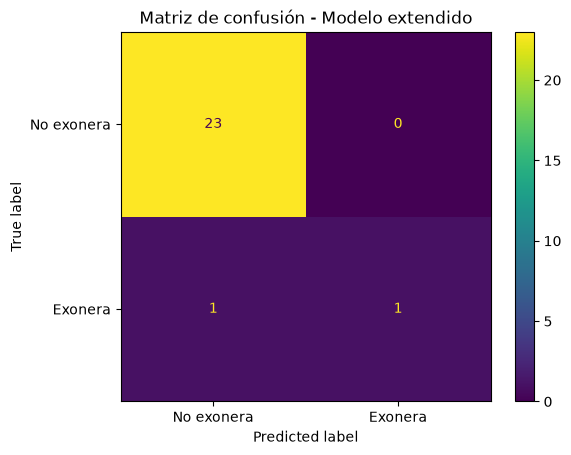

In [98]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_extendido,
    display_labels=["No exonera", "Exonera"]
)

plt.title("Matriz de confusión - Modelo extendido")
plt.show()

## 19. Validación cruzada estratificada

Debido al tamaño reducido de la muestra, la comparación principal se realiza también mediante validación cruzada estratificada de 5 folds.

Se utiliza exactamente la misma división de folds para ambos modelos.

In [99]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_actual = cross_validate(
    modelo_actual,
    X_actual,
    y,
    cv=cv,
    scoring=metricas
)

cv_extendido = cross_validate(
    modelo_extendido,
    X_extendido,
    y,
    cv=cv,
    scoring=metricas
)

resultados_cv_actual = pd.DataFrame({
    metrica: cv_actual[f"test_{metrica}"]
    for metrica in metricas
})

resultados_cv_extendido = pd.DataFrame({
    metrica: cv_extendido[f"test_{metrica}"]
    for metrica in metricas
})

resumen_cv = pd.DataFrame({
    "Actual - Media": resultados_cv_actual.mean(),
    "Actual - Desv.": resultados_cv_actual.std(),
    "Extendido - Media": resultados_cv_extendido.mean(),
    "Extendido - Desv.": resultados_cv_extendido.std()
}).T

resumen_cv.round(3)

c:\Users\hugoc\miniconda3\envs\ml1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hugoc\miniconda3\envs\ml1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,accuracy,precision,recall,f1,roc_auc
Actual - Media,0.960,0.800,0.600,0.667,0.978
Actual - Desv.,0.042,0.447,0.418,0.408,0.023
Extendido - Media,0.960,0.800,0.600,0.667,1.000
Extendido - Desv.,0.042,0.447,0.418,0.408,0.000


## 20. Aporte de las variables del prerrequisito

Para facilitar la interpretación se calcula la diferencia entre las métricas promedio del modelo extendido y las del modelo actual.

In [100]:
mejora_cv = (
    resultados_cv_extendido.mean()
    - resultados_cv_actual.mean()
)

pd.DataFrame(
    mejora_cv,
    columns=["Diferencia modelo extendido - actual"]
).round(3)

,Diferencia modelo extendido - actual
accuracy,0.000
precision,0.000
recall,0.000
f1,0.000
roc_auc,0.022


### Interpretación

La comparación debe centrarse especialmente en `F1`, `Recall` y `ROC-AUC`, debido al desbalance de clases.

- Una diferencia positiva indica que incorporar el prerrequisito mejoró esa métrica.
- Una diferencia cercana a cero indica que aporta poca información adicional.
- Una diferencia negativa indica que, en esta muestra, la nueva información no mejoró la generalización.

El resultado debe interpretarse considerando que esta extensión dispone de menos estudiantes que el análisis original.

## 21. Conclusión de la extensión

La incorporación del rendimiento previo en Ecuaciones Diferenciales o Cálculo 3
permitió evaluar si el desempeño en una asignatura prerrequisito aporta información
adicional para estimar la posibilidad de alcanzar una firma de 71 puntos o más
en Métodos Numéricos.

De los 260 estudiantes de la cohorte original, 100 poseen información del
prerrequisito en el segundo ciclo de 2024. Dentro de este subconjunto, 10
estudiantes alcanzaron el umbral de exoneración.

Al comparar el modelo actual con el modelo extendido, no se observaron mejoras
en Accuracy, Precision, Recall ni F1-score. Ambos modelos obtuvieron resultados
promedio equivalentes en estas métricas.

Sin embargo, el modelo extendido presentó una mejora en ROC-AUC, pasando de
aproximadamente 0.978 a 1.000 en la validación cruzada. Esto sugiere que la
información del prerrequisito puede aportar capacidad adicional para ordenar
correctamente a los estudiantes según su probabilidad estimada de exonerar,
aunque dicha mejora no se traduzca en una mayor cantidad de clasificaciones
correctas utilizando el umbral actual.

Los resultados deben interpretarse con cautela debido al reducido tamaño del
subconjunto analizado y, especialmente, a la baja cantidad de casos positivos.

La principal limitación es que solo se dispone del historial de prerrequisitos
correspondiente al segundo ciclo de 2024. Incorporar otros períodos académicos
permitiría aumentar la cobertura y evaluar con mayor solidez el verdadero aporte
del rendimiento en asignaturas prerrequisito.